# Handwritten Digit Classification using CNN and RNN

## 1. Import Libraries

In [19]:
import torch
import torch.nn as nn

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import torch.optim as optim

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = MNIST(root="../data", train=True, download=True, transform=transform)
testset = MNIST(root="../data", train=False, download=True, transform=transform)

## 3. Create Training and Validation Sets

The original MNIST training dataset contains 60,000 images.  
We split it into training and validation sets so that the validation set can be used to monitor model performance during development.

The test set is kept separate and will be used only for the final evaluation of the CNN and RNN models.

In [ ]:
train_size = int(.9 * len(trainset))
val_size = len(trainset) - train_size

train_data, val_data = random_split(
    trainset, 
    [train_size, val_size]
) 

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(testset))

Training samples: 54000
Validation samples: 6000
Test samples: 10000


## 4. Create DataLoaders

In [7]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

In [8]:
train_images, train_labels = next(iter(trainloader))
val_images, val_labels = next(iter(valloader))
test_images, test_labels = next(iter(testloader))

print("Training batch shape:", train_images.shape)
print("Validation batch shape:", val_images.shape)
print("Test batch shape:", test_images.shape)

Training batch shape: torch.Size([32, 1, 28, 28])
Validation batch shape: torch.Size([32, 1, 28, 28])
Test batch shape: torch.Size([32, 1, 28, 28])


## 5. Explore the Dataset

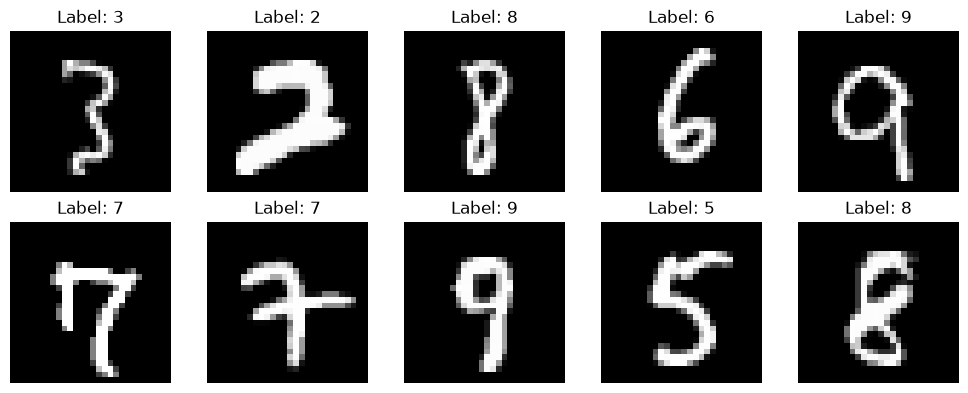

In [9]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print("Image shape:", images[0].shape)
print("Label:", labels[0].item())
print("Minimum pixel value:", images[0].min().item())
print("Maximum pixel value:", images[0].max().item())

Image shape: torch.Size([1, 28, 28])
Label: 3
Minimum pixel value: -1.0
Maximum pixel value: 1.0



## 6. Build CNN Model


In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            #input 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 64 x 7 x 7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 128 x 3 x 3
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 3 * 3 , 128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)

        return x

    

In [20]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())